In [1]:
import pandas as pd
import numpy as np

# Read dataset
df = pd.read_csv("Dataset_Day10.csv")

# Columns containing missing values
cols = ['Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction']

# Replace 0 with NaN
for col in cols:
    df[col] = df[col].replace(0, np.nan)

# Fill missing values using median
for col in cols:
    df[col] = df[col].fillna(df[col].median())

# Remove outliers using IQR method
for col in cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    OutlierRows = df[(df[col] < lower) | (df[col] > upper)]
    df = df.drop(OutlierRows.index)

print("Shape after cleaning:", df.shape)
print(df.head())

Shape after cleaning: (719, 7)
   Pregnancies  Glucose  BloodPressure   BMI  DiabetesPedigreeFunction  Age  \
0            6    148.0           72.0  33.6                     0.627   50   
1            1     85.0           66.0  26.6                     0.351   31   
2            8    183.0           64.0  23.3                     0.672   32   
3            1     89.0           66.0  28.1                     0.167   21   
5            5    116.0           74.0  25.6                     0.201   30   

   Outcome  
0        1  
1        0  
2        1  
3        0  
5        0  


In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# Separate input features and target variable
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=50
)

# Create the model with default parameters
dt = DecisionTreeClassifier()

# Train the model
dt.fit(X_train, y_train)

# Predict on test data
y_pred = dt.predict(X_test)

# Print model performance metrics
print("Accuracy =", accuracy_score(y_test, y_pred))
print("Precision =", precision_score(y_test, y_pred))
print("Recall =", recall_score(y_test, y_pred))
print("F1 Score =", f1_score(y_test, y_pred))

Accuracy = 0.7222222222222222
Precision = 0.6545454545454545
Recall = 0.631578947368421
F1 Score = 0.6428571428571429


In [4]:
# Different values of max_depth and max_leaf_nodes
max_depth = [1, 3, 5, 7, 9, 11, 13]
max_leaf_nodes = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]

# List to store model performance
PerfData = []

# Try different combinations of max_depth and max_leaf_nodes
for d in max_depth:

    for l in max_leaf_nodes:

        # Create Decision Tree model using entropy criterion
        dt = DecisionTreeClassifier(
            criterion='entropy',
            max_depth=d,
            max_leaf_nodes=l,
            random_state=50
        )

        # Train the model
        dt.fit(X_train, y_train)

        # Predict on test data
        y_pred = dt.predict(X_test)

        # Store performance metrics
        row = [
            d,
            l,
            precision_score(y_test, y_pred),
            recall_score(y_test, y_pred),
            accuracy_score(y_test, y_pred),
            f1_score(y_test, y_pred)
        ]

        PerfData.append(row)

# Convert list to DataFrame
PerfData = pd.DataFrame(
    PerfData,
    columns=[
        "Max Depth",
        "Max Leaf Nodes",
        "Precision",
        "Recall",
        "Accuracy",
        "F1 Score"
    ]
)

# Display the row corresponding to maximum F1 score
print("Best Parameter Combination:")
print(
    PerfData[
        PerfData["F1 Score"] == PerfData["F1 Score"].max()
    ]
)

Best Parameter Combination:
    Max Depth  Max Leaf Nodes  Precision    Recall  Accuracy  F1 Score
29          5              13   0.733333  0.578947      0.75  0.647059
30          5              15   0.733333  0.578947      0.75  0.647059
31          5              17   0.733333  0.578947      0.75  0.647059


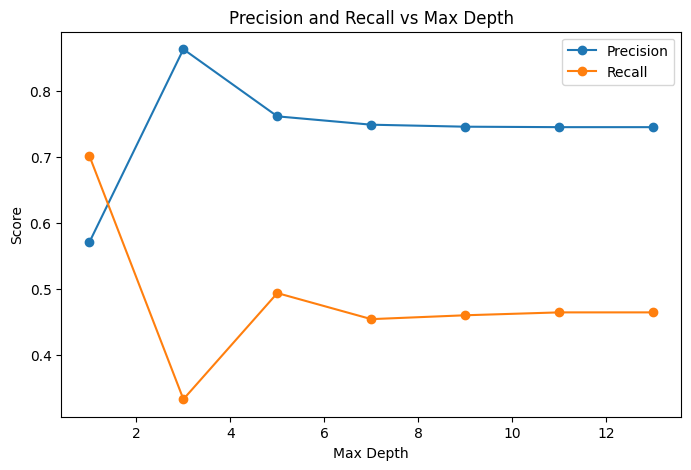

In [5]:
import matplotlib.pyplot as plt
# Plot Precision and Recall against max_depth
plt.figure(figsize=(8,5))

plt.plot(
    PerfData.groupby("Max Depth")["Precision"].mean(),
    marker='o',
    label='Precision'
)

plt.plot(
    PerfData.groupby("Max Depth")["Recall"].mean(),
    marker='o',
    label='Recall'
)

plt.xlabel("Max Depth")
plt.ylabel("Score")
plt.title("Precision and Recall vs Max Depth")

plt.legend()

plt.show()

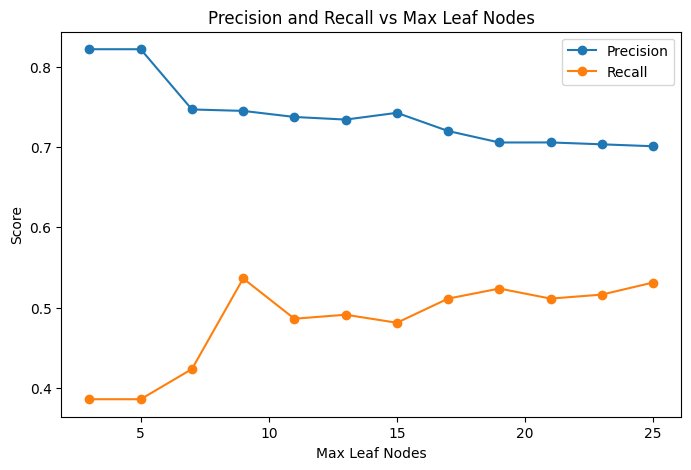

In [6]:
# Plot Precision and Recall against max_leaf_nodes
plt.figure(figsize=(8,5))

plt.plot(
    PerfData.groupby("Max Leaf Nodes")["Precision"].mean(),
    marker='o',
    label='Precision'
)

plt.plot(
    PerfData.groupby("Max Leaf Nodes")["Recall"].mean(),
    marker='o',
    label='Recall'
)

plt.xlabel("Max Leaf Nodes")
plt.ylabel("Score")
plt.title("Precision and Recall vs Max Leaf Nodes")

plt.legend()

plt.show()